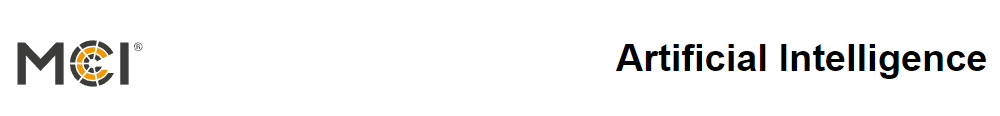

---

# 02 Feature Extraction with VGG19

As always we need to import all the relevant packages for this lecture.

In [1]:
# Import all packages needed in this notebook.
import numpy as np
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.models.vgg import vgg19
from torchvision.models import VGG19_Weights
from torchvision.transforms import functional as F
import torch
import os
import glob
from sklearn.model_selection import train_test_split
import shutil

# 1. Feature Extraction 


Feature extraction with deep convolutional neural networks like VGG19 and ResNet152 is a powerful technique in computer vision for transforming raw images into meaningful representations. VGG19, developed by University of Oxford, uses a simple and uniform architecture composed of sequential 3×3 convolutional layers, which makes it effective at capturing hierarchical visual features such as edges, textures, and object parts. In contrast, ResNet152, introduced by Microsoft Research, leverages residual connections that allow gradients to flow more easily through its very deep structure (152 layers), enabling the extraction of more complex and abstract features without suffering from vanishing gradient problems. When used for feature extraction, both models are typically pre-trained on large datasets like ImageNet and applied by removing their final classification layers, allowing the intermediate activations to serve as compact, high-level feature vectors for tasks such as image classification, clustering, or transfer learning.

In [3]:
def read_Img_Torch(input_img, using_Cuda :bool = False):
    
    if type(input_img) != str:
        raise ValueError("input must be string)")
        
    img_Orig = Image.open(input_img)
    image_np = np.array(img_Orig)/255.0
    
    if image_np.ndim != 3:
        raise ValueError("input image must have 3 channels)")
    image_np = np.transpose(image_np, (2, 0, 1))
    
    if using_Cuda:
        return torch.tensor(image_np, dtype=torch.float32).cuda().unsqueeze(0).float()
    else:
        return torch.tensor(image_np, dtype=torch.float32).unsqueeze(0).float()
            

Let's display both the shape of the image tensor and the image itself.

torch.Size([1, 3, 400, 770])


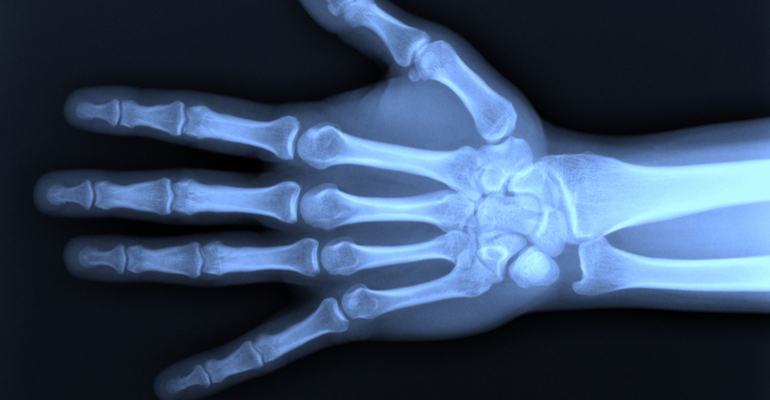

In [ ]:
#img_input = read_Img_Torch("../Data/Test_Images/MRI_Brain.jpg")
img_input = read_Img_Torch("../Data/Test_Images/CT_Hand.jpg")
#img_input = read_Img_Torch("../Data/Test_Images/Cycling_Optimal_Position.jpg")
#img_input = read_Img_Torch("../Data/Test_Images/Volleyball_Game_Scene.jpg")

print(img_input.shape)
F.to_pil_image(img_input[0])

## 1.1. What is VGG19?

Well, to put it in nutshell:

VGG19 consists of 19 weight layers:

* 16 convolutional layers
* 3 fully connected (dense) layers

It uses:

* Small 3×3 convolution filters
* ReLU activation
* Max pooling (2×2) to reduce spatial size

That is the structure:
Input: 224 × 224 × 3 (RGB image) --> Any image that has a higher resolution will be scaled

Block 1:
- Conv3-64
- Conv3-64
- MaxPool

Block 2:
- Conv3-128
- Conv3-128
- MaxPool

Block 3:
- Conv3-256
- Conv3-256
- Conv3-256
- Conv3-256
- MaxPool

Block 4:
- Conv3-512
- Conv3-512
- Conv3-512
- Conv3-512
- MaxPool

Block 5:
- Conv3-512
- Conv3-512
- Conv3-512
- Conv3-512
- MaxPool

Classifier:
- Fully Connected (4096)
- Fully Connected (4096)
- Fully Connected (1000) → Softmax

We could use VGG19 directly as classifier, but we are more interested in the feature extraction abilities of the pretrained network.
How can we understand the feature extraction better?

#### TASK:

--> We can have a look at the so called feature maps.

We can extract the feature maps (outputs) of specific layers. As we can see above there are 5 blocks. Let's see how the feature maps look like from: 
* Block 1 Conv 1 and 2 
* Block 2 Conv 1 and 2
* Block 3 Conv 1, 2, 3 and 4 
* Block 4 Conv 1, 2, 3 and 4 
* Block 5 Conv 1, 2, 3 and 4 


In [12]:
# Code here

If you were not able to do this on your own, here is the final solution:

In [13]:
def Feat_Extr_Vgg(image_ip, layer_no, using_Cuda :bool = False):
    outputs = {}
    def activation(name):
        def hook(module, input, output):
            outputs[name] = output.detach()
        return hook
    
    if using_Cuda: model = vgg19(weights=VGG19_Weights.DEFAULT).cuda()
    else:
        model = vgg19(weights=VGG19_Weights.DEFAULT)
                
        
   
    if layer_no in range(0,2):
        if layer_no == 0: model.features[0].register_forward_hook(activation('layer1'))
        elif layer_no == 1: model.features[2].register_forward_hook(activation('layer1'))
        
    elif layer_no in range(2,4):
        if layer_no == 2: model.features[5].register_forward_hook(activation('layer1'))
        elif layer_no == 3: model.features[7].register_forward_hook(activation('layer1'))
            
    elif layer_no in range(4,8):
        if layer_no == 4: model.features[10].register_forward_hook(activation('layer1'))
        elif layer_no == 5: model.features[12].register_forward_hook(activation('layer1'))
        elif layer_no == 6: model.features[14].register_forward_hook(activation('layer1'))
        elif layer_no == 7: model.features[16].register_forward_hook(activation('layer1'))
        
    
    elif layer_no in range(8,12):
        if layer_no == 8: model.features[19].register_forward_hook(activation('layer1'))
        elif layer_no == 9: model.features[21].register_forward_hook(activation('layer1'))
        elif layer_no == 10: model.features[23].register_forward_hook(activation('layer1'))
        elif layer_no == 11: model.features[25].register_forward_hook(activation('layer1'))
        
    
    elif layer_no in range(12,15):
        if layer_no == 12: model.features[28].register_forward_hook(activation('layer1'))
        elif layer_no == 13: model.features[30].register_forward_hook(activation('layer1'))
        elif layer_no == 14: model.features[32].register_forward_hook(activation('layer1'))
        elif layer_no == 15: model.features[34].register_forward_hook(activation('layer1'))
            
    else:
        raise ValueError("This layer isn't present")   
             
    
    vis = model(image_ip)
    feature_map = outputs['layer1'].detach().cpu().squeeze(0) # 128x128x64


    feature_map = abs(feature_map)
    gray_scale = torch.sum(feature_map,0) # 128x128x1
    processed_features = (gray_scale - gray_scale.min()) / (gray_scale.max() - gray_scale.min())  # Normalize feature map
    
    
    features_Numpy = processed_features.numpy()
    return features_Numpy


In [ ]:
# Initialize an empty list to store feature maps
feature_maps_vgg19 = []

# Loop through the layers of interest (0 to 14) and extract feature maps
for layer_no in range(15):
    # Extract feature map for the current layer
    print(f"Extracting feature map for layer {layer_no}")
    feature_map = Feat_Extr_Vgg(img_input, layer_no, using_Cuda=False)
    feature_maps_vgg19.append(feature_map)


Extracting feature map for layer 0
Extracting feature map for layer 1
Extracting feature map for layer 2
Extracting feature map for layer 3
Extracting feature map for layer 4
Extracting feature map for layer 5
Extracting feature map for layer 6
Extracting feature map for layer 7
Extracting feature map for layer 8
Extracting feature map for layer 9
Extracting feature map for layer 10
Extracting feature map for layer 11
Extracting feature map for layer 12
Extracting feature map for layer 13
Extracting feature map for layer 14


The feature maps have various sizes. To have the possibility to compare them properly, we resize them so plotting and interpreting them becomes feasible.

In [17]:
# Initialize an empty list to store resized feature maps
resized_feature_maps_vgg19 = []

# Desired size for the resized feature maps
target_size = (300, 300)

# Resize each feature map
for feature_map in feature_maps_vgg19:
    # Resize the feature map using bicubic interpolation
    resized_map = cv.resize(feature_map, target_size, interpolation=cv.INTER_CUBIC)
    resized_feature_maps_vgg19.append(resized_map)


Now we can have a look at the feature maps.

#### TASK:

Plot all feature maps

In [ ]:
# code here

If you were not able to do this on your own, here is the final solution:

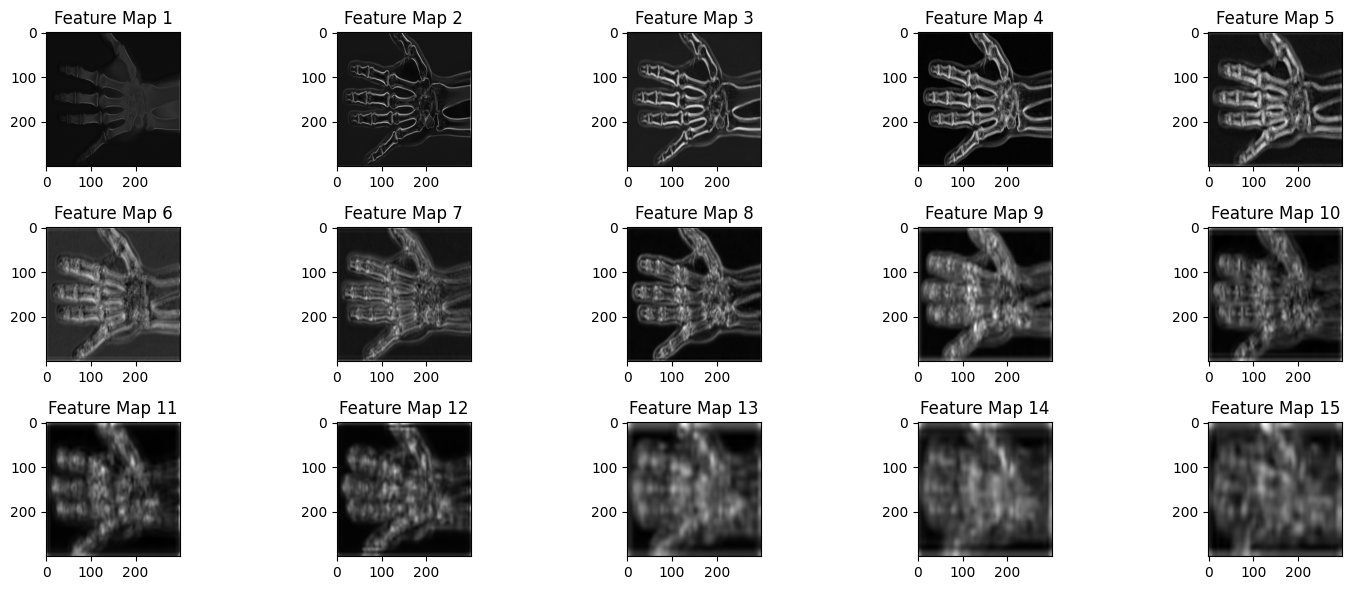

In [18]:
# The code goes here

# Set up a 2x5 grid for displaying the resized feature maps
fig, axes = plt.subplots(3, 5, figsize=(15, 6))

# Flatten the axes array for easy indexing
axes = axes.ravel()

# Loop through each resized feature map and display it
for i, resized_map in enumerate(resized_feature_maps_vgg19):
    # Display the resized feature map on the subplot
    axes[i].imshow(resized_map, cmap='gray')
    axes[i].set_title(f'Feature Map {i + 1}')
    

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


#### TASK:

Interpret what you see there. Try to answer wuestions like:
* What is happening in all the CNN Layers?
* Where are high level features detected and where low level?
* When should I use VGG19?

Also, redo the lecture with other images and discuss the results with your peers.